In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [3]:
train = pd.read_csv("data/train.csv")
store = pd.read_csv("data/store.csv")

df = train.merge(store, on="Store", how="left")

C:\Users\MY\AppData\Local\Temp\ipykernel_18012\2251189782.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("data/train.csv")


In [4]:
train.head(3)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1


In [5]:
store.head(3)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"


In [6]:
df = train.merge(store, on="Store", how="left")

In [7]:
df.head(3)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"


In [8]:
df.shape

(1017209, 18)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [10]:
df["Date"] = pd.to_datetime(df["Date"])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

## Data Cleaning / Preprocessing

In [12]:
df.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

In [13]:
df.isnull().sum().sort_values(ascending=False)

Promo2SinceWeek              508031
PromoInterval                508031
Promo2SinceYear              508031
CompetitionOpenSinceYear     323348
CompetitionOpenSinceMonth    323348
CompetitionDistance            2642
DayOfWeek                         0
Store                             0
Date                              0
Sales                             0
StoreType                         0
SchoolHoliday                     0
StateHoliday                      0
Promo                             0
Open                              0
Customers                         0
Assortment                        0
Promo2                            0
dtype: int64

In [14]:
df["CompetitionDistance"] = df["CompetitionDistance"].fillna(df["CompetitionDistance"].median())

df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].fillna(0)

df["CompetitionOpenSinceYear"] = df["CompetitionOpenSinceYear"].fillna(0)

df["Promo2SinceWeek"] = df["Promo2SinceWeek"].fillna(0)

df["Promo2SinceYear"] = df["Promo2SinceYear"].fillna(0)

df["PromoInterval"] = df["PromoInterval"].fillna(0)

In [15]:
df.isnull().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

In [16]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["WeekOfYear"] = df["Date"].dt.isocalendar().week

In [17]:
df.head(2)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,4,2015-07-31,5263,555,1,1,0,1,c,...,9.0,2008.0,0,0.0,0.0,0,2015,7,31,31
1,2,4,2015-07-31,6064,625,1,1,0,1,a,...,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31


## EDA

In [18]:
df["Open"].value_counts()

Open
1    844392
0    172817
Name: count, dtype: int64

In [19]:
df = df[df["Open"] == 1]

In [20]:
df.shape

(844392, 22)

Closed days have deterministic zero sales. Including them would bias the model and distort seasonality patterns. Therefore, operational days are filtered to model true demand.

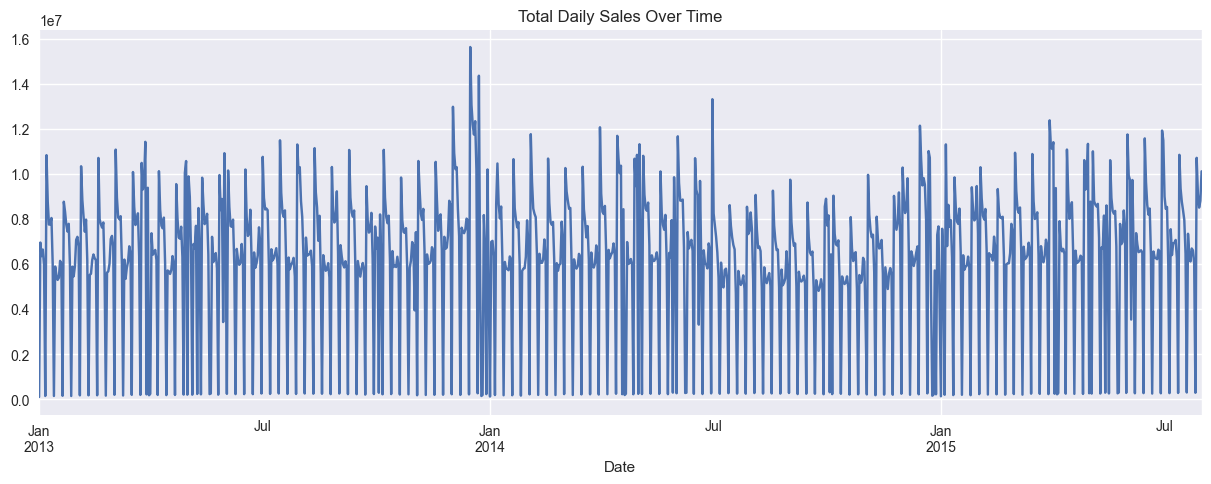

In [21]:
daily_sales = df.groupby("Date")["Sales"].sum()

plt.figure(figsize=(15,5))
daily_sales.plot()
plt.title("Total Daily Sales Over Time")
plt.show()

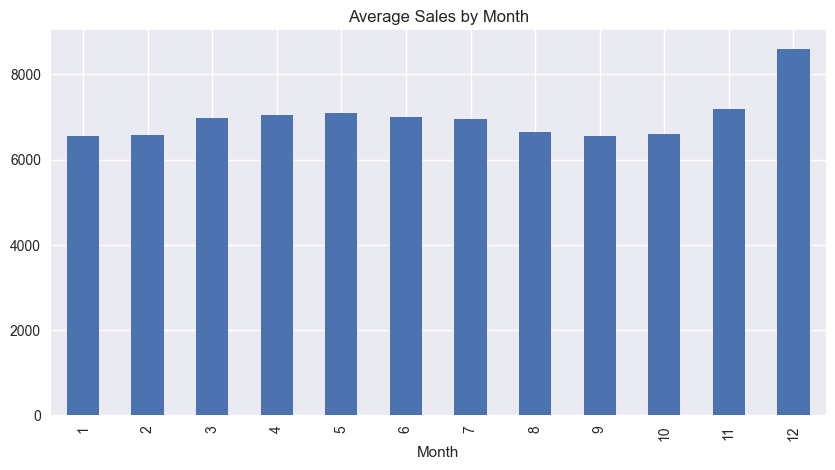

In [22]:
df.groupby("Month")["Sales"].mean().plot(kind="bar", figsize=(10,5))
plt.title("Average Sales by Month")
plt.show()

The plot shows strong yearly seasonality, with December having the highest average sales, likely due to holiday demand. Mid-year months have comparatively lower sales. This indicates that month-level seasonal features should be included in the forecasting model.

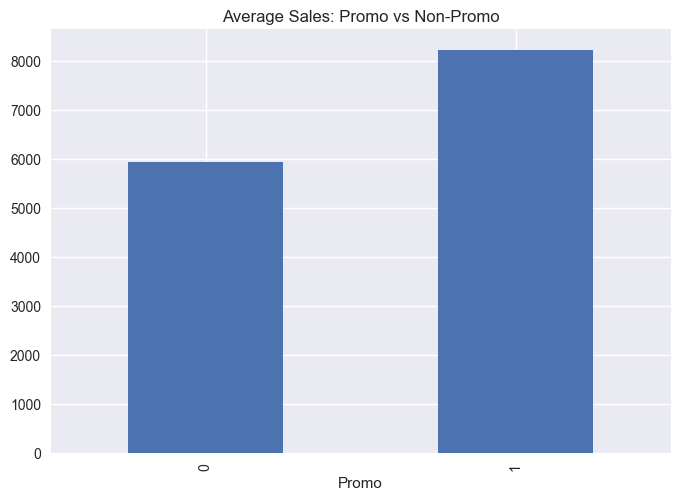

In [23]:
df.groupby("Promo")["Sales"].mean().plot(kind="bar")
plt.title("Average Sales: Promo vs Non-Promo")
plt.show()

In [24]:
df.groupby("Promo")["Sales"].mean()

Promo
0    5929.407603
1    8228.281239
Name: Sales, dtype: float64

Stores running promotions generate significantly higher average sales compared to stores without promotions. On average, sales during promotions (~8228) are substantially higher than non-promotional periods (~5929), indicating that promotional campaigns positively impact revenue.

In [25]:
monthly_sales = df.groupby(["Month", "Promo"])["Sales"].mean()

In [26]:
monthly_sales = monthly_sales.reset_index()

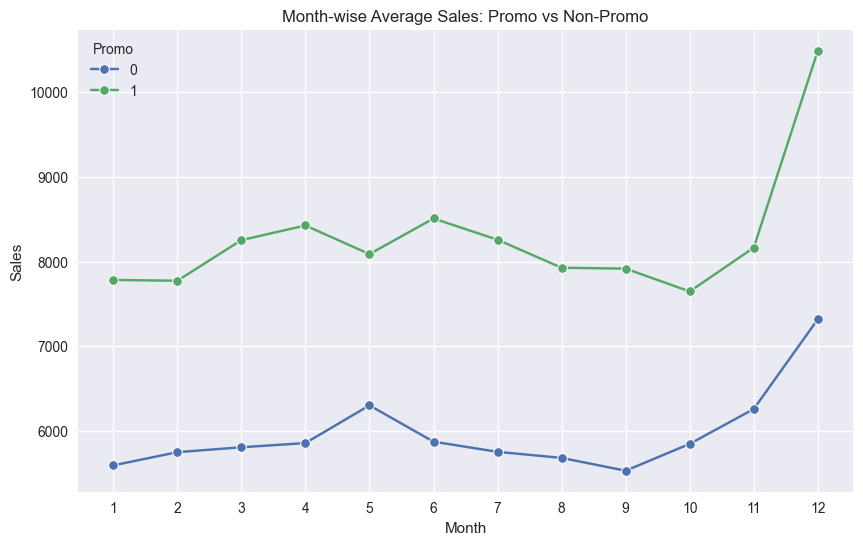

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.lineplot(data=monthly_sales, x="Month", y="Sales", hue="Promo", marker="o")

plt.title("Month-wise Average Sales: Promo vs Non-Promo")
plt.xticks(range(1,13))
plt.show()

In [28]:
df.groupby(["StoreType", "Promo"])["Sales"].mean()

StoreType  Promo
a          0         5808.500091
           1         8304.102317
b          0         9566.861686
           1        11307.994108
c          0         6028.063255
           1         8041.995526
d          0         5855.268289
           1         8017.828656
Name: Sales, dtype: float64

In [29]:
store_sales = df.groupby(["StoreType", "Promo"])["Sales"].mean().reset_index()

In [30]:
store_pivot = store_sales.pivot(index="StoreType", columns="Promo", values="Sales")
store_pivot.columns = ["Non_Promo", "Promo"]
store_pivot = store_pivot.reset_index()

store_pivot

,StoreType,Non_Promo,Promo
0,a,5808.500091,8304.102317
1,b,9566.861686,11307.994108
2,c,6028.063255,8041.995526
3,d,5855.268289,8017.828656


In [31]:
store_pivot["Lift_%"] = (
    (store_pivot["Promo"] - store_pivot["Non_Promo"])
    / store_pivot["Non_Promo"]
) * 100

store_pivot

,StoreType,Non_Promo,Promo,Lift_%
0,a,5808.500091,8304.102317,42.964658
1,b,9566.861686,11307.994108,18.199619
2,c,6028.063255,8041.995526,33.409276
3,d,5855.268289,8017.828656,36.933583


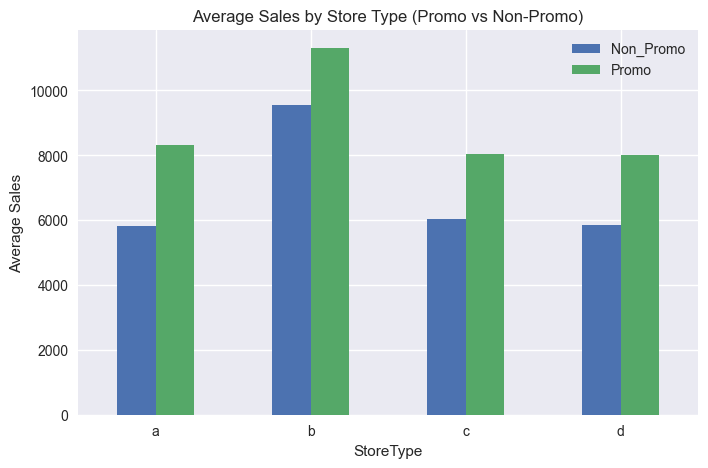

In [32]:
import matplotlib.pyplot as plt

store_pivot.set_index("StoreType")[["Non_Promo", "Promo"]].plot(kind="bar", figsize=(8,5))

plt.title("Average Sales by Store Type (Promo vs Non-Promo)")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.show()

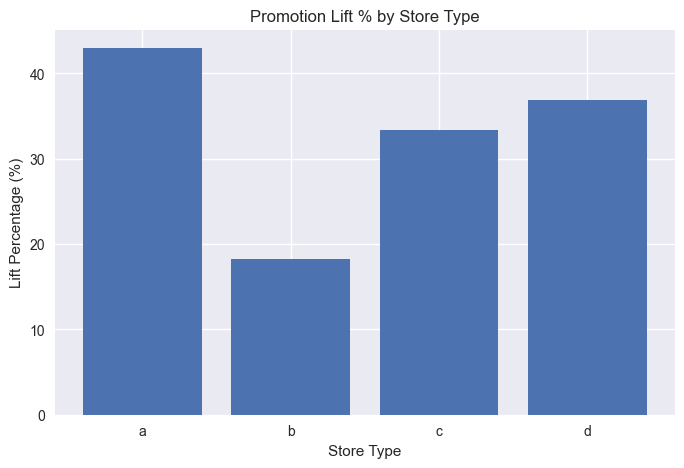

In [33]:
plt.figure(figsize=(8,5))

plt.bar(store_pivot["StoreType"], store_pivot["Lift_%"])

plt.title("Promotion Lift % by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Lift Percentage (%)")
plt.show()

Promotional campaigns increase sales across all store types. While Store Type B generates the highest absolute sales, Store Type A exhibits the highest promotional lift (~43%), indicating stronger responsiveness to promotional activities. This suggests that promotional strategies may yield better ROI when targeted toward promotion-sensitive store segments.

<Axes: xlabel='Promo', ylabel='Sales'>

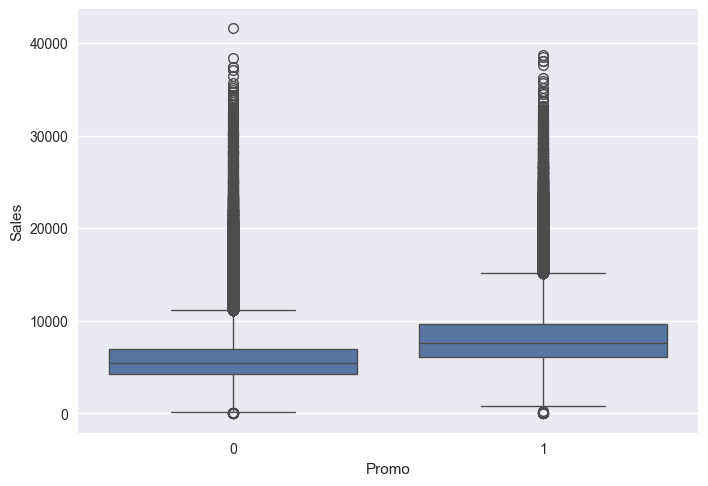

In [34]:
sns.boxplot(x="Promo", y="Sales", data=df)

The box plot shows that when Promo = 1 (promotion active), the median sales are higher compared to Promo = 0 (no promotion). This indicates that promotions have a positive impact on sales. Additionally, the sales distribution during promotions is more spread out, suggesting greater variability in sales when promotions are running. There are also several outliers in both cases, representing unusually high sales values.

In [35]:
df.corr(numeric_only=True)

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,Year,Month,Day,WeekOfYear
Store,1.000000,0.000346,0.007710,0.033977,NaN,-0.000012,0.000512,-0.027084,-0.032555,-0.008152,0.007736,0.010857,0.007768,0.000301,0.001365,-0.000119,0.001292
DayOfWeek,0.000346,1.000000,-0.178736,-0.097266,NaN,-0.289265,-0.139315,0.005533,-0.000834,-0.001303,-0.003241,-0.002736,-0.003238,0.002102,-0.019723,0.008534,-0.014402
Sales,0.007710,-0.178736,1.000000,0.823597,NaN,0.368145,0.038617,-0.035852,-0.018370,0.005266,-0.127596,-0.058476,-0.127621,0.036169,0.073600,-0.051849,0.074472
Customers,0.033977,-0.097266,0.823597,1.000000,NaN,0.182846,0.024902,-0.147798,-0.021006,0.001666,-0.202232,-0.130841,-0.202204,-0.000822,0.053856,-0.035405,0.053774
Open,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Promo,-0.000012,-0.289265,0.368145,0.182846,NaN,1.000000,0.028964,-0.002393,0.000711,0.000990,-0.000324,-0.000802,-0.000326,0.023994,-0.006408,-0.126452,0.006950
SchoolHoliday,0.000512,-0.139315,0.038617,0.024902,NaN,0.028964,1.000000,-0.004258,-0.000131,0.000126,-0.008245,-0.008062,-0.008248,-0.038679,0.118485,0.038081,0.079604
CompetitionDistance,-0.027084,0.005533,-0.035852,-0.147798,NaN,-0.002393,-0.004258,1.000000,-0.032083,-0.001218,-0.141317,-0.123999,-0.141380,0.000633,0.003888,-0.000227,0.003697
CompetitionOpenSinceMonth,-0.032555,-0.000834,-0.018370,-0.021006,NaN,0.000711,-0.000131,-0.032083,1.000000,0.785326,-0.082561,-0.109522,-0.082488,-0.000532,-0.001328,-0.000210,-0.001300
CompetitionOpenSinceYear,-0.008152,-0.001303,0.005266,0.001666,NaN,0.000990,0.000126,-0.001218,0.785326,1.000000,-0.098571,-0.125080,-0.098503,-0.000156,-0.000758,-0.000336,-0.000742


Sales show a strong positive correlation with the number of customers (0.82) and a moderate positive relationship with promotions (0.37). Most other variables such as competition distance, holidays, and calendar features show very weak correlations with sales, indicating limited influence.

In [36]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,4,2015-07-31,5263,555,1,1,0,1,c,...,9.0,2008.0,0,0.0,0.0,0,2015,7,31,31
1,2,4,2015-07-31,6064,625,1,1,0,1,a,...,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31
2,3,4,2015-07-31,8314,821,1,1,0,1,a,...,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
3,4,4,2015-07-31,13995,1498,1,1,0,1,c,...,9.0,2009.0,0,0.0,0.0,0,2015,7,31,31
4,5,4,2015-07-31,4822,559,1,1,0,1,a,...,4.0,2015.0,0,0.0,0.0,0,2015,7,31,31


## Feature Engineering

In [38]:
df = pd.get_dummies(
    df,
    columns=["StateHoliday", "StoreType", "Assortment", "PromoInterval"],
    drop_first=True
)

In [39]:
df.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,...,StateHoliday_b,StateHoliday_c,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c,"PromoInterval_Feb,May,Aug,Nov","PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec"
0,1,4,5263,555,1,1,1,1270.0,9.0,2008.0,...,False,False,False,True,False,False,False,False,False,False
1,2,4,6064,625,1,1,1,570.0,11.0,2007.0,...,False,False,False,False,False,False,False,False,True,False
2,3,4,8314,821,1,1,1,14130.0,12.0,2006.0,...,False,False,False,False,False,False,False,False,True,False
3,4,4,13995,1498,1,1,1,620.0,9.0,2009.0,...,False,False,False,True,False,False,True,False,False,False
4,5,4,4822,559,1,1,1,29910.0,4.0,2015.0,...,False,False,False,False,False,False,False,False,False,False


In [40]:
from scipy.stats import ttest_ind

promo_sales = df[df["Promo"] == 1]["Sales"]
nonpromo_sales = df[df["Promo"] == 0]["Sales"]

t_stat, p_value = ttest_ind(promo_sales, nonpromo_sales)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 363.8446754265649
P-value: 0.0


In [41]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
X.head()

,Store,DayOfWeek,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,...,StateHoliday_b,StateHoliday_c,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c,"PromoInterval_Feb,May,Aug,Nov","PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec"
0,1,4,555,1,1,1,1270.0,9.0,2008.0,0,...,False,False,False,True,False,False,False,False,False,False
1,2,4,625,1,1,1,570.0,11.0,2007.0,1,...,False,False,False,False,False,False,False,False,True,False
2,3,4,821,1,1,1,14130.0,12.0,2006.0,1,...,False,False,False,False,False,False,False,False,True,False
3,4,4,1498,1,1,1,620.0,9.0,2009.0,0,...,False,False,False,True,False,False,True,False,False,False
4,5,4,559,1,1,1,29910.0,4.0,2015.0,0,...,False,False,False,False,False,False,False,False,False,False


In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 938.5520953186394
RMSE: 1292.6928875500832
R2: 0.8267216897129144


The Linear Regression model achieved an R² score of 0.83, indicating strong predictive performance. However, the MAE and RMSE values suggest that prediction errors still exist, particularly for high sales values. This indicates that more complex models such as Random Forest or Gradient Boosting may further improve prediction accuracy.

In [45]:
from sklearn.ensemble import RandomForestRegressor

In [46]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
y_pred_rf = rf.predict(X_test)

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Random Forest Results")

print("MAE:", mean_absolute_error(y_test, y_pred_rf))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

print("R2:", r2_score(y_test, y_pred_rf))

Random Forest Results
MAE: 316.8227856631079
RMSE: 475.3116593042301
R2: 0.9765733374999337


The Random Forest model significantly outperformed Linear Regression, achieving an R² score of 0.973. This indicates that the model explains approximately 97% of the variance in store sales. The low MAE (~335) suggests that the model predictions are very close to the actual sales values. Tree-based models perform well because they capture nonlinear relationships between features such as promotions, store types, seasonality, and holidays.

## Lag Features

In [49]:
df["Date"] = pd.to_datetime(df[["Year","Month","Day"]])

In [50]:
df = df.sort_values(["Store","Date"])

In [51]:
df["Lag_1"] = df.groupby("Store")["Sales"].shift(1)
df["Lag_7"] = df.groupby("Store")["Sales"].shift(7)
df["Lag_30"] = df.groupby("Store")["Sales"].shift(30)

In [52]:
df["Rolling_Mean_7"] = df.groupby("Store")["Sales"].shift(1).rolling(7).mean()
df["Rolling_Mean_30"] = df.groupby("Store")["Sales"].shift(1).rolling(30).mean()

In [53]:
df = df.dropna()

In [54]:
df.isnull().sum()

Store                             0
DayOfWeek                         0
Sales                             0
Customers                         0
Open                              0
Promo                             0
SchoolHoliday                     0
CompetitionDistance               0
CompetitionOpenSinceMonth         0
CompetitionOpenSinceYear          0
Promo2                            0
Promo2SinceWeek                   0
Promo2SinceYear                   0
Year                              0
Month                             0
Day                               0
WeekOfYear                        0
StateHoliday_0                    0
StateHoliday_a                    0
StateHoliday_b                    0
StateHoliday_c                    0
StoreType_b                       0
StoreType_c                       0
StoreType_d                       0
Assortment_b                      0
Assortment_c                      0
PromoInterval_Feb,May,Aug,Nov     0
PromoInterval_Jan,Apr,Jul,Oc

In [55]:
train = df[df["Date"] < "2015-01-01"]
test = df[df["Date"] >= "2015-01-01"]

In [56]:
X_train = train.drop(["Sales","Date"], axis=1)
y_train = train["Sales"]

X_test = test.drop(["Sales","Date"], axis=1)
y_test = test["Sales"]

In [57]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [58]:
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 454.82519392904965
RMSE: 650.7180772417624
R2: 0.9540073063658102


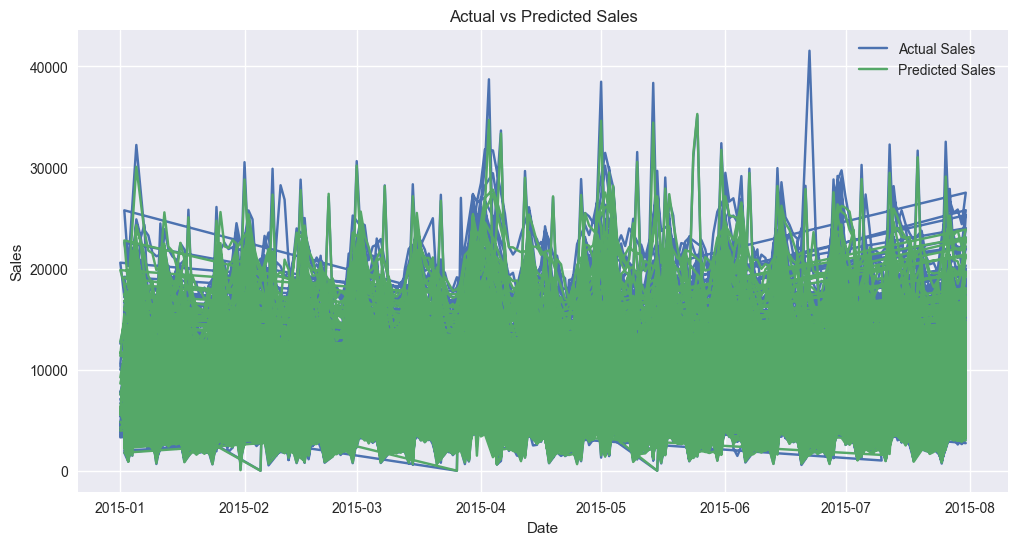

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(test["Date"], y_test, label="Actual Sales")
plt.plot(test["Date"], y_pred, label="Predicted Sales")

plt.legend()
plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

The Random Forest model performed very well in predicting store sales, achieving an R² score of 0.95, which means the model explains about 95% of the variation in sales. The MAE (454.8) and RMSE (650.7) indicate relatively small prediction errors compared to the overall sales values. From the Actual vs Predicted plot, the predicted sales closely follow the real sales trend, showing that the model captures the underlying patterns effectively. Overall, the model provides accurate and reliable sales predictions.

In [60]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R2:", r2_score(y_test, y_pred_xgb))

MAE: 435.7574768066406
RMSE: 610.4012256295034
R2: 0.9595299363136292


Among all models tested, XGBoost achieved the best performance with the lowest MAE and RMSE and the highest R² score. This indicates that XGBoost captures the complex relationships between promotional activities, seasonality, and sales more effectively than other models.

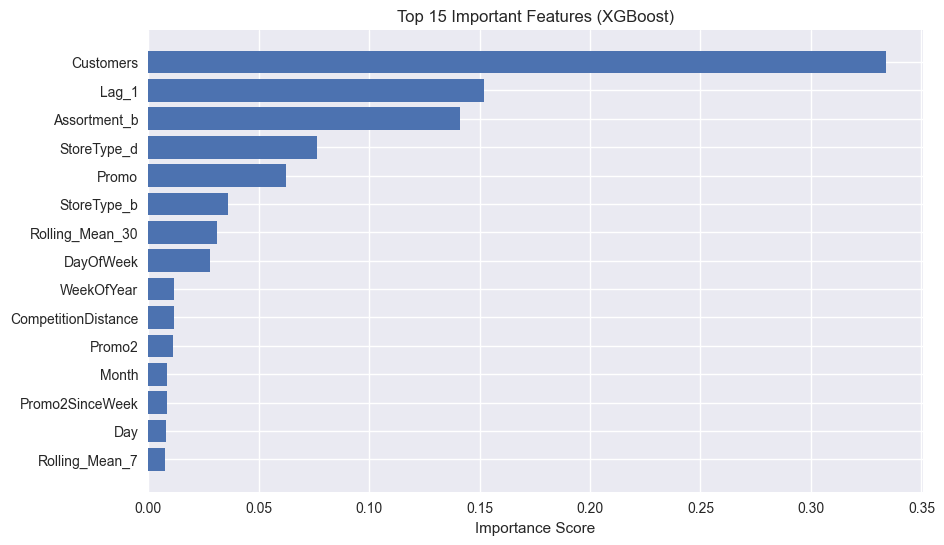

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = xgb.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

# Sort
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"][:15], feature_importance["Importance"][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features (XGBoost)")
plt.xlabel("Importance Score")
plt.show()

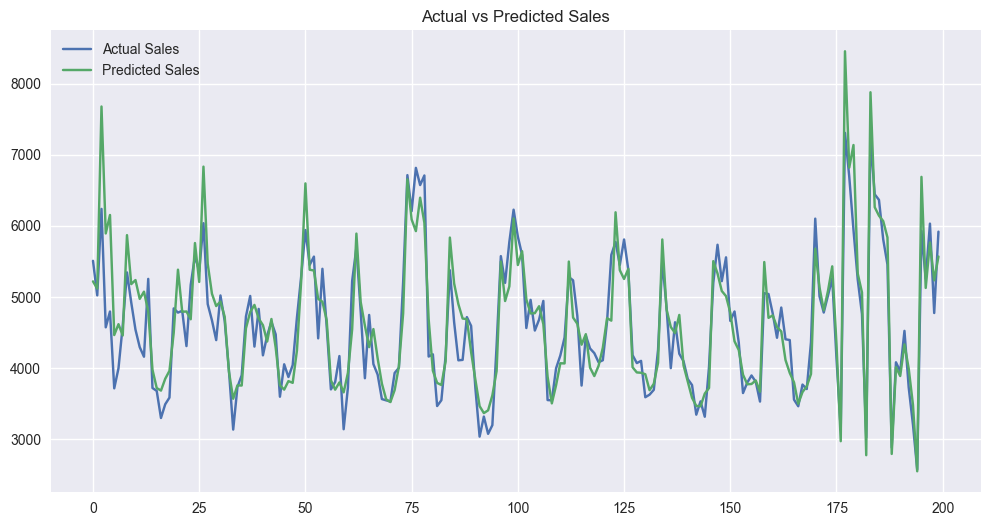

In [63]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:200], label="Actual Sales")
plt.plot(y_pred_xgb[:200], label="Predicted Sales")

plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [77]:
future_preds = []

last_data = df.iloc[-1:].copy()

for i in range(30):

    pred = xgb.predict(last_data)[0]
    
    future_preds.append(pred)

    # update lag features
    last_data["Lag_30"] = last_data["Lag_7"]
    last_data["Lag_7"] = last_data["Lag_1"]
    last_data["Lag_1"] = pred

    future_df = pd.DataFrame({
    "Day": range(1,31),
    "Predicted_Sales": future_preds
})

print(future_df)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:Date: datetime64[ns]

In [69]:
future_df = pd.DataFrame({
    "Day": range(1, future_days + 1),
    "Predicted_Sales": future_predictions
})

future_df.head()

,Day,Predicted_Sales
0,1,8966.789062
1,2,8966.789062
2,3,8966.789062
3,4,8966.789062
4,5,8966.789062


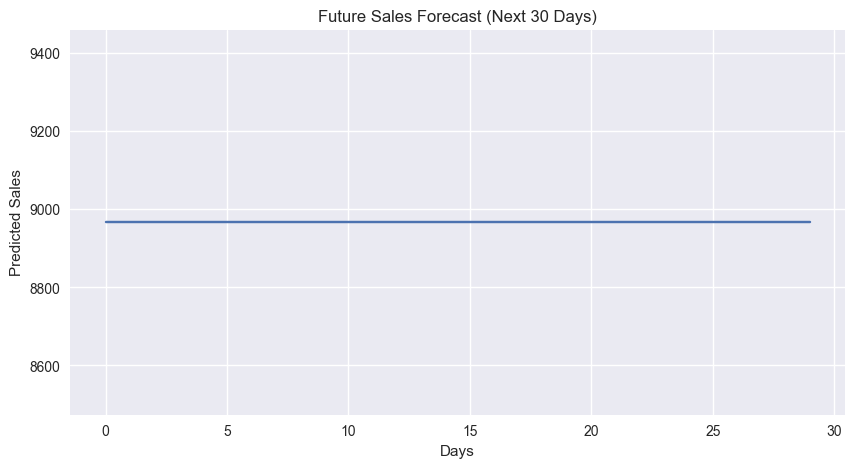

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(future_df["Predicted_Sales"])
plt.title("Future Sales Forecast (Next 30 Days)")
plt.xlabel("Days")
plt.ylabel("Predicted Sales")

plt.show()

In [75]:
print(X_future)

        Store  DayOfWeek  Customers  Open  Promo  SchoolHoliday  \
810970   1115          4        538     1      1              1   

        CompetitionDistance  CompetitionOpenSinceMonth  \
810970               5350.0                        0.0   

        CompetitionOpenSinceYear  Promo2  ...  Assortment_b  Assortment_c  \
810970                       0.0       1  ...         False          True   

        PromoInterval_Feb,May,Aug,Nov  PromoInterval_Jan,Apr,Jul,Oct  \
810970                          False                          False   

        PromoInterval_Mar,Jun,Sept,Dec   Lag_1   Lag_7  Lag_30  \
810970                            True  8405.0  6150.0  5549.0   

        Rolling_Mean_7  Rolling_Mean_30  
810970     7676.285714           7091.6  

[1 rows x 33 columns]
